# Associative Kalman Filters

Owing to its implementation in [cuthbert](https://github.com/state-space-models/cuthbert), dynestyx supports [associate scan Kalman filtering ](https://arxiv.org/abs/1905.13002), which perform Kalman filtering in $\mathcal{O}(\log T)$ time, where $T$ is the length of the time series. 

This is configurable in dynestyx via the `associative` parameter (default: `True`) in the KFConfig:
- **Sequential scan**: `KFConfig(filter_source="cuthbert", associative=False)`
- **Associative scan**: `KFConfig(filter_source="cuthbert", associative=True)`

In this notebook, we illustrate the performance gains of using `associative=True` as the length of a time series increases. We use a fixed linear-Gaussian `LTI_discrete` model, generate one long synthetic data set, and then benchmark prefixes of that same series.

The benchmark uses the low-level `compute_cuthbert_filter(...)` directly, excludes compilation time from the reported timings, and measures median runtime over a few repeated runs per sequence length. This is simply to create as direct of a benchmark as possible; we generally expect similar gains for longer time series in practice.

In [1]:
import statistics
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx.inference.filter_configs import KFConfig
from dynestyx.inference.integrations.cuthbert.discrete import compute_cuthbert_filter
from dynestyx.simulators import DiscreteTimeSimulator

In [2]:
LENGTHS = [2**k for k in range(5, 15)]
MAX_LEN = max(LENGTHS)
REPEATS = 7

dynamics = dsx.LTI_discrete(
    A=jnp.array([[0.85, 0.15], [0.0, 0.9]]),
    Q=0.05 * jnp.eye(2),
    H=jnp.array([[1.0, 0.0]]),
    R=jnp.array([[0.2**2]]),
)


def lti_model(obs_times=None, obs_values=None, predict_times=None):
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

full_obs_times = jnp.arange(MAX_LEN, dtype=jnp.float32)
predictive = Predictive(lti_model, num_samples=1, exclude_deterministic=False)

with DiscreteTimeSimulator():
    synthetic = predictive(jr.PRNGKey(0), predict_times=full_obs_times)

full_obs_values = synthetic["f_observations"][0, 0]

print(f"Generated synthetic observations with shape: {full_obs_values.shape}")
print(f"Benchmark lengths: {LENGTHS}")

Generated synthetic observations with shape: (16384, 1)
Benchmark lengths: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]


In [3]:
def build_runner(length, associative):
    obs_times = full_obs_times[:length]
    obs_values = full_obs_values[:length]
    filter_config = KFConfig(filter_source="cuthbert", associative=associative)

    @jax.jit
    def run_filter():
        marginal_loglik, states = compute_cuthbert_filter(
            dynamics,
            filter_config,
            obs_times=obs_times,
            obs_values=obs_values,
        )
        return marginal_loglik, states.mean

    return run_filter


def benchmark_runner(runner, repeats=REPEATS):
    warm_loglik, warm_means = runner()
    warm_loglik.block_until_ready()
    warm_means.block_until_ready()

    timings = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        marginal_loglik, means = runner()
        marginal_loglik.block_until_ready()
        means.block_until_ready()
        timings.append(time.perf_counter() - t0)
    return statistics.median(timings)


results = []
for length in LENGTHS:
    seq_runner = build_runner(length, associative=False)
    assoc_runner = build_runner(length, associative=True)

    seq_time = benchmark_runner(seq_runner)
    assoc_time = benchmark_runner(assoc_runner)

    seq_loglik, seq_means = seq_runner()
    assoc_loglik, assoc_means = assoc_runner()
    seq_loglik.block_until_ready()
    assoc_loglik.block_until_ready()
    seq_means.block_until_ready()
    assoc_means.block_until_ready()

    assert jnp.allclose(seq_loglik, assoc_loglik, rtol=1e-3, atol=1e-3)
    assert jnp.allclose(seq_means, assoc_means, rtol=1e-3, atol=1e-3)

    results.append(
        {
            "length": length,
            "sequential_s": seq_time,
            "associative_s": assoc_time,
            "speedup": seq_time / assoc_time,
        }
    )

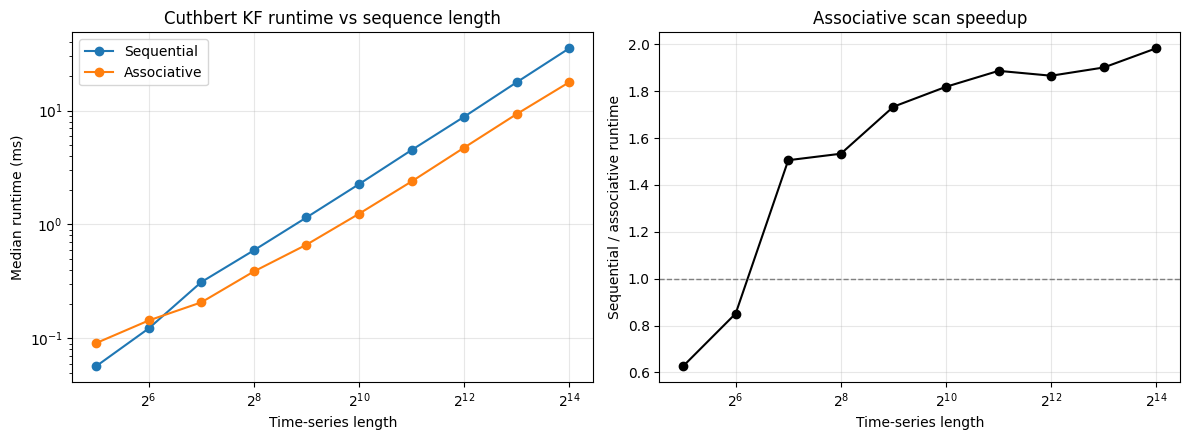

In [4]:
lengths = [row["length"] for row in results]
sequential_ms = [1_000.0 * row["sequential_s"] for row in results]
associative_ms = [1_000.0 * row["associative_s"] for row in results]
speedups = [row["speedup"] for row in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(lengths, sequential_ms, marker="o", label="Sequential")
axes[0].plot(lengths, associative_ms, marker="o", label="Associative")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Time-series length")
axes[0].set_ylabel("Median runtime (ms)")
axes[0].set_title("Cuthbert KF runtime vs sequence length")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(lengths, speedups, marker="o", color="black")
axes[1].axhline(1.0, linestyle="--", color="gray", linewidth=1)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Time-series length")
axes[1].set_ylabel("Sequential / associative runtime")
axes[1].set_title("Associative scan speedup")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation

A few things are worth keeping in mind when reading these curves:

- The associative and sequential filters should agree numerically for the exact linear-Gaussian model used here; the benchmark asserts agreement before recording each point.
- The reported timings exclude JIT compilation time by warming each mode and sequence length once before measuring.
- The crossover point is hardware-dependent. On short time series, the associative path may provide little benefit or even be slightly slower because the parallel scan has its own overhead.
- On longer series, the associative path is typically a good idea.